In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
df = pd.read_csv(r"G:\663P\dataset\data\updated_dataset_2_metrics_f.csv")

print(f"dev Dataset shape: {df.shape}")
print(f"agent Dataset shape: {df.shape}")
def compare_groups(metric):
    a = df[df["group"] == "agent"][metric].dropna()
    h = df[df["group"] == "human"][metric].dropna()
    
    stat, p = mannwhitneyu(a, h, alternative="two-sided")
    
    # Effect size (rank-biserial)
    n1, n2 = len(a), len(h)
    effect = 1 - (2 * stat) / (n1 * n2)
    
    print(f"\n=== {metric} ===")
    print(f"Agent mean: {a.mean():.4f}")
    print(f"Human mean: {h.mean():.4f}")
    print(f"Agent median: {a.median():.4f}")
    print(f"Human median: {h.median():.4f}")
    print(f"p-value: {p}")
    print(f"effect size: {effect} {interpret_effect(effect)}")
agents = {}
for agent in df['label']:
    if pd.isna(agent):
        agent = 'human'
    if agent in agents:
        agents[agent] += 1
    else:
        agents[agent] = 1
print(agents)
# print(f"Repos in agentic {len(df_a["repo"].value_counts())}")
# print(f"Repos in human {len(df_h["repo"].value_counts())}")



# mean median mode of functions per repo
# Count functions per repo
# funcs_per_repo_a = df_a.groupby("repo").size()
# funcs_per_repo_h = df_h.groupby("repo").size()
def summarize(name, series):
    print(f"\n{name}")
    print(f"Mean:   {series.mean():.2f}")
    print(f"Median: {series.median():.2f}")
    print(f"Mode:   {series.mode().iloc[0] if not series.mode().empty else 'N/A'}")
    print(f"Std:    {series.std():.2f}")
    print(f"Min:    {series.min()}")
    print(f"Max:    {series.max()}")

# summarize("Agent", funcs_per_repo_a)
# summarize("Human", funcs_per_repo_h)

dev Dataset shape: (13467, 30)
agent Dataset shape: (13467, 30)
{'Copilot': 1538, 'Cursor': 1355, 'Claude_Code': 2368, 'Devin': 922, 'OpenAI_Codex': 366, 'human': 6918}


In [14]:
# Combine datasets
# df = pd.read_csv(r"/Volumes/T7-Shield/663P/dataset/data/updated_dataset_metrics.csv")
df = pd.read_csv(r"G:\663f\dataset\data\updated_dataset_2_metrics_f.csv")

# Compute rate of documentation **before dropping rows**
for metric in ["doc_entropy", "doc_code_overlap", "doc_redundancy"]:
    agent_total = len(df[df['group'] == 'agent'])
    agent_doc = df[df['group'] == 'agent'][metric].notna().sum()
    human_total = len(df[df['group'] == 'human'])
    human_doc = df[df['group'] == 'human'][metric].notna().sum()
    
    print(f"Documentation rate for {metric} - agent: {agent_doc / agent_total:.2f}")
    print(f"Documentation rate for {metric} - human: {human_doc / human_total:.2f}")

# Now drop obvious garbage rows if you want to clean for analysis
numeric_cols = [
    "doc_lines", "doc_entropy", "doc_readability",
    "doc_code_overlap", "doc_redundancy",
    "cyclomatic_complexity", "sloc",
    "semgrep_findings_count",
    "turnover_c5", "turnover_c10", "turnover_c20",
    "turnover_m1", "turnover_m3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])
print("Final dataset after cleaning:", df.shape)
print()
print('documentation rate by agent')
agents2 = {}
for agent in df['label']:
    if pd.isna(agent):
        agent = 'human'
    if agent in agents2:
        agents2[agent] += 1
    else:
        agents2[agent] = 1
print(agents2)

for key in agents2:
    print(f"{key}: {agents2[key]/agents[key]}")

Documentation rate for doc_entropy - agent: 0.56
Documentation rate for doc_entropy - human: 0.32
Documentation rate for doc_code_overlap - agent: 0.56
Documentation rate for doc_code_overlap - human: 0.32
Documentation rate for doc_redundancy - agent: 0.56
Documentation rate for doc_redundancy - human: 0.32
Final dataset after cleaning: (5884, 30)

documentation rate by agent
{'Copilot': 1100, 'Cursor': 662, 'Claude_Code': 1533, 'Devin': 305, 'OpenAI_Codex': 53, 'human': 2231}
Copilot: 0.7152145643693107
Cursor: 0.4885608856088561
Claude_Code: 0.6473817567567568
Devin: 0.33080260303687636
OpenAI_Codex: 0.1448087431693989
human: 0.32249204972535417


In [15]:
def interpret_effect(e):
    if abs(e) < 0.1:
        return "negligible"
    elif abs(e) < 0.3:
        return "small"
    elif abs(e) < 0.5:
        return "medium"
    else:
        return "large"
def compare_groups(metric):
    a = df[df["group"] == "agent"][metric].dropna()
    h = df[df["group"] == "human"][metric].dropna()
    
    stat, p = mannwhitneyu(a, h, alternative="two-sided")
    
    # Effect size (rank-biserial)
    n1, n2 = len(a), len(h)
    effect = 1 - (2 * stat) / (n1 * n2)
    
    print(f"\n=== {metric} ===")
    print(f"Agent mean: {a.mean():.4f}")
    print(f"Human mean: {h.mean():.4f}")
    print(f"Agent median: {a.median():.4f}")
    print(f"Human median: {h.median():.4f}")
    print(f"p-value: {p}")
    print(f"effect size: {effect} {interpret_effect(effect)}")
    
    return a, h

def bootstrap_ci(a, h, n_boot=1000):
    diffs = []
    for _ in range(n_boot):
        a_sample = a.sample(frac=1, replace=True)
        h_sample = h.sample(frac=1, replace=True)
        diffs.append(a_sample.median() - h_sample.median())
    return np.percentile(diffs, [2.5, 97.5])

metrics_rq1 = ["doc_code_overlap", "doc_redundancy", "doc_entropy"]

results_rq1 = {}
for m in metrics_rq1:
    results_rq1[m] = compare_groups(m)
    
for m in metrics_rq1:
    a, h = compare_groups(m)
    
    ci_low, ci_high = bootstrap_ci(a, h)
    print(f"Median diff 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")




print(f"Median diff 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")


=== doc_code_overlap ===
Agent mean: 0.2888
Human mean: 0.2080
Agent median: 0.2500
Human median: 0.1667
p-value: 2.891875338880582e-43
effect size: -0.21319024182429036 small

=== doc_redundancy ===
Agent mean: 0.1302
Human mean: 0.1443
Agent median: 0.0769
Human median: 0.0833
p-value: 0.11200344770753239
effect size: 0.02348940955058887 negligible

=== doc_entropy ===
Agent mean: 3.1117
Human mean: 3.4220
Agent median: 3.1542
Human median: 3.4183
p-value: 7.780438582382782e-17
effect size: 0.12923917675469332 small

=== doc_code_overlap ===
Agent mean: 0.2888
Human mean: 0.2080
Agent median: 0.2500
Human median: 0.1667
p-value: 2.891875338880582e-43
effect size: -0.21319024182429036 small
Median diff 95% CI: [0.0833, 0.0965]

=== doc_redundancy ===
Agent mean: 0.1302
Human mean: 0.1443
Agent median: 0.0769
Human median: 0.0833
p-value: 0.11200344770753239
effect size: 0.02348940955058887 negligible
Median diff 95% CI: [-0.0242, 0.0119]

=== doc_entropy ===
Agent mean: 3.1117
Human 

In [16]:
from statsmodels.stats.multitest import multipletests

p_values = []
for m in metrics_rq1:
    a = df[df["group"] == "agent"][m].dropna()
    h = df[df["group"] == "human"][m].dropna()
    _, p = mannwhitneyu(a, h, alternative="two-sided")
    p_values.append(p)

adjusted = multipletests(p_values, method='holm')

for i, m in enumerate(metrics_rq1):
    print(f"{m} adjusted p-value: {adjusted[1][i]}")

doc_code_overlap adjusted p-value: 8.675626016641746e-43
doc_redundancy adjusted p-value: 0.11200344770753239
doc_entropy adjusted p-value: 1.5560877164765564e-16


RQ1 - doc_code_overlap: Mann-Whitney U=4943655.0, p-value=2.8919e-43
RQ1 - doc_redundancy: Mann-Whitney U=3979204.0, p-value=1.1200e-01


C:\Users\otten\AppData\Local\Temp\ipykernel_22684\2052449561.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\otten\AppData\Local\Temp\ipykernel_22684\2052449561.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\otten\AppData\Local\Temp\ipykernel_22684\2052449561.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


RQ1 - doc_entropy: Mann-Whitney U=3548282.0, p-value=7.7804e-17


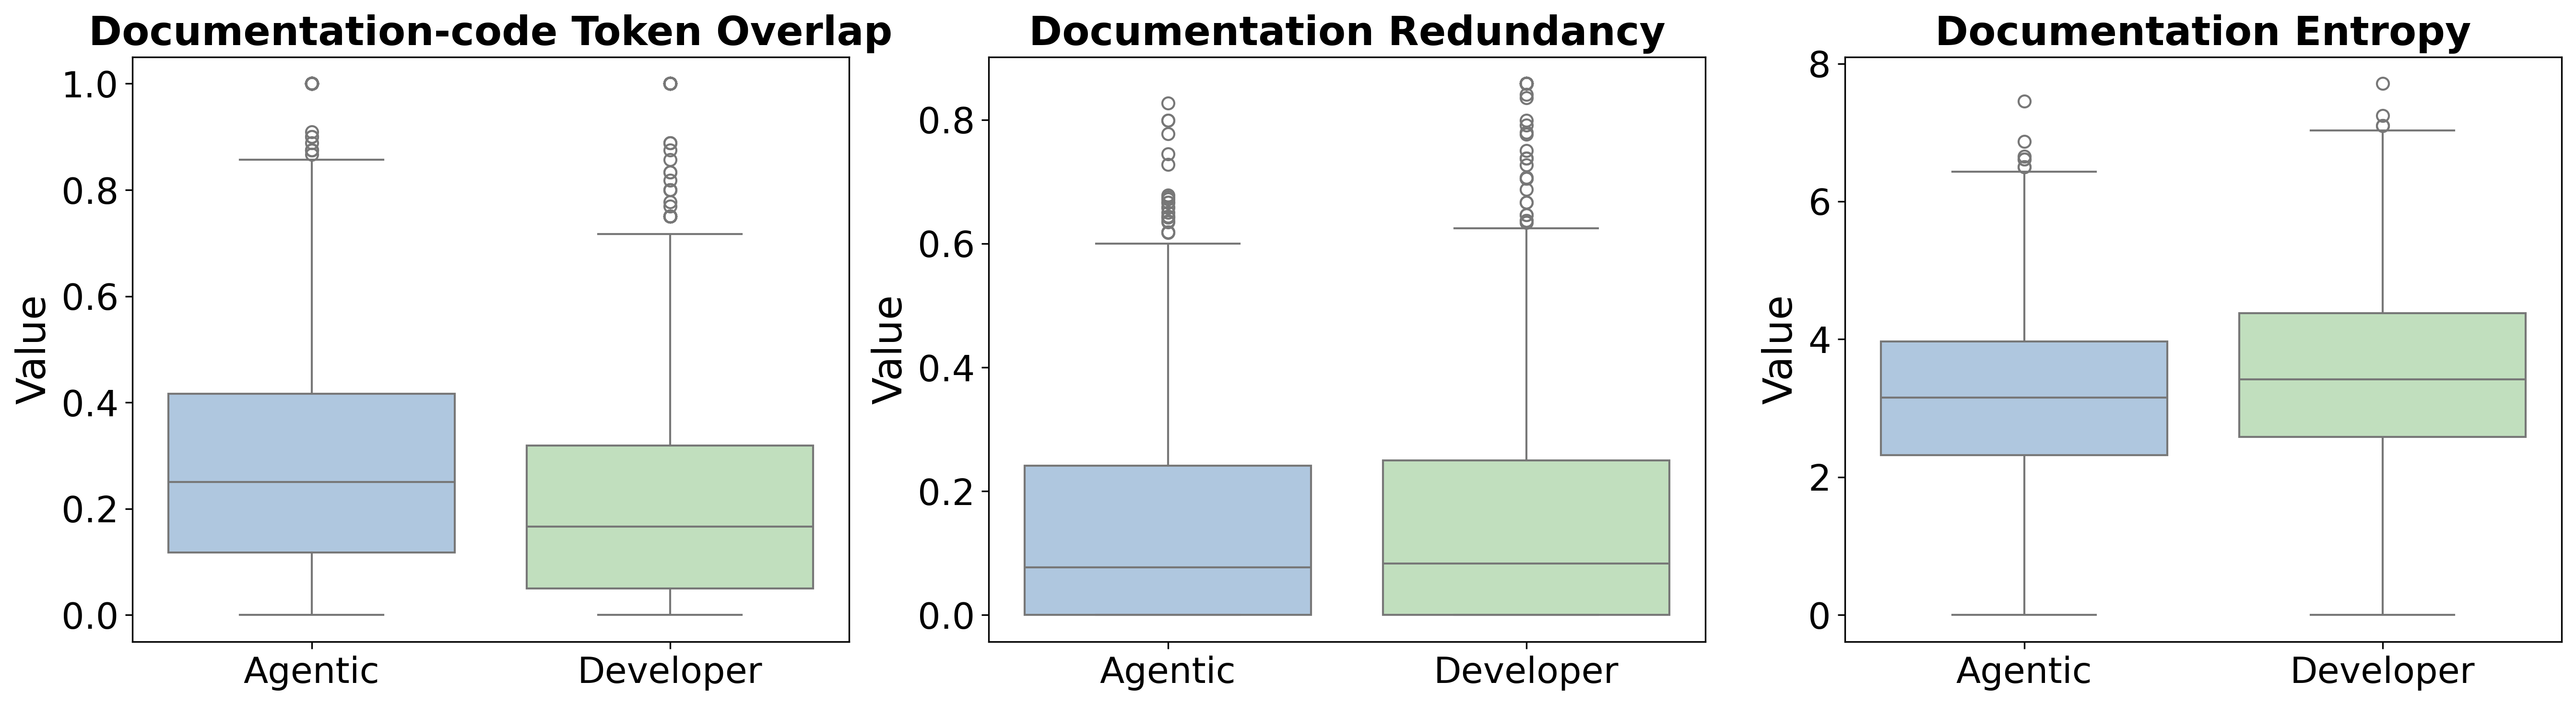

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

metrics_rq1 = ['doc_code_overlap', 'doc_redundancy', 'doc_entropy']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi =300)

# Custom palette
palette={"Agentic": "#A7C7E7", "Developer": "#BDE5B8"}
# Pretty names for titles
pretty_titles = {
    "doc_code_overlap": "Documentation-code Token Overlap",
    "doc_redundancy": "Documentation Redundancy",
    "doc_entropy": "Documentation Entropy"
}

# Rename groups for plotting only
df_plot = df.copy()
df_plot["group"] = df_plot["group"].map({
    "agent": "Agentic",
    "human": "Developer"
})

for i, metric in enumerate(metrics_rq1):
    sns.boxplot(
        x='group',
        y=metric,
        data=df_plot,
        ax=axes[i],
        palette={"Agentic": "#A7C7E7", "Developer": "#BDE5B8"},
    )
    axes[i].tick_params(axis='x', labelsize=18)

    # Y-axis tick numbers
    axes[i].tick_params(axis='y', labelsize=18)
    
    axes[i].set_title(pretty_titles[metric], fontsize=20, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value',fontsize=20)
    
    # Statistical Test (keep original df to avoid mapping issues)
    agent_vals = df[df['group'] == 'agent'][metric].dropna()
    human_vals = df[df['group'] == 'human'][metric].dropna()
    stat, p = mannwhitneyu(agent_vals, human_vals, alternative='two-sided')
    
    print(f"RQ1 - {metric}: Mann-Whitney U={stat}, p-value={p:.4e}")

plt.tight_layout()
plt.show()

In [19]:
import re

def tokenize(text): #this tokenizer will split words based on the aplabetical content, 
    if not text: # "def tokenize(text): boom1 bang" -> print(tokenize("def tokenize(text): boom1 bang"))
        return []
    return re.findall(r"[A-Za-z_][A-Za-z0-9_]*", text.lower())

# --- Documentation Length Analysis (consistent tokenizer) ---

# 1. Create token count feature using your tokenizer
df["doc_token_count"] = df["doc_text"].apply(lambda x: len(tokenize(x)))

# Optional: inspect distribution
print("Token count stats:")
print(df["doc_token_count"].describe())

# 2. Compare groups
a_len, h_len = compare_groups("doc_token_count")

# 3. Bootstrap CI for median difference
ci_low, ci_high = bootstrap_ci(a_len, h_len)
print(f"Median diff 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

# 4. Correlations (important for interpretation)
print("\nCorrelations with token count:")
for m in ["doc_code_overlap", "doc_entropy", "doc_redundancy"]:
    corr = df[["doc_token_count", m]].corr().iloc[0, 1]
    print(f"{m}: {corr:.4f}")

import numpy as np
import pandas as pd

agent = df[df["group"] == "agent"]["doc_token_count"].dropna()
human = df[df["group"] == "human"]["doc_token_count"].dropna()

percentiles = [50, 75, 80, 85, 90, 95, 97, 99, 99.5, 99.9]

rows = []
for p in percentiles:
    a_val = np.percentile(agent, p)
    h_val = np.percentile(human, p)
    rows.append({
        "percentile": p,
        "agent": a_val,
        "human": h_val,
        "diff": a_val - h_val,
        "ratio": (a_val / h_val) if h_val > 0 else np.nan
    })

table = pd.DataFrame(rows)
print(table)


Token count stats:
count    5884.000000
mean       24.203773
std        61.144288
min         1.000000
25%         5.000000
50%        11.000000
75%        24.000000
max      1497.000000
Name: doc_token_count, dtype: float64

=== doc_token_count ===
Agent mean: 17.6411
Human mean: 34.9494
Agent median: 11.0000
Human median: 12.0000
p-value: 2.0507509618796267e-12
effect size: 0.10899829604079492 small
Median diff 95% CI: [-2.0000, 0.0000]

Correlations with token count:
doc_code_overlap: -0.0255
doc_entropy: 0.4692
doc_redundancy: 0.5268
   percentile    agent  human     diff     ratio
0        50.0   11.000   12.0   -1.000  0.916667
1        75.0   22.000   29.0   -7.000  0.758621
2        80.0   26.000   36.0  -10.000  0.722222
3        85.0   31.000   45.0  -14.000  0.688889
4        90.0   38.800   63.0  -24.200  0.615873
5        95.0   54.000  108.0  -54.000  0.500000
6        97.0   69.440  170.0 -100.560  0.408471
7        99.0  102.960  743.3 -640.340  0.138517
8        99.5  

C:\Users\otten\AppData\Local\Temp\ipykernel_22684\2469362659.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


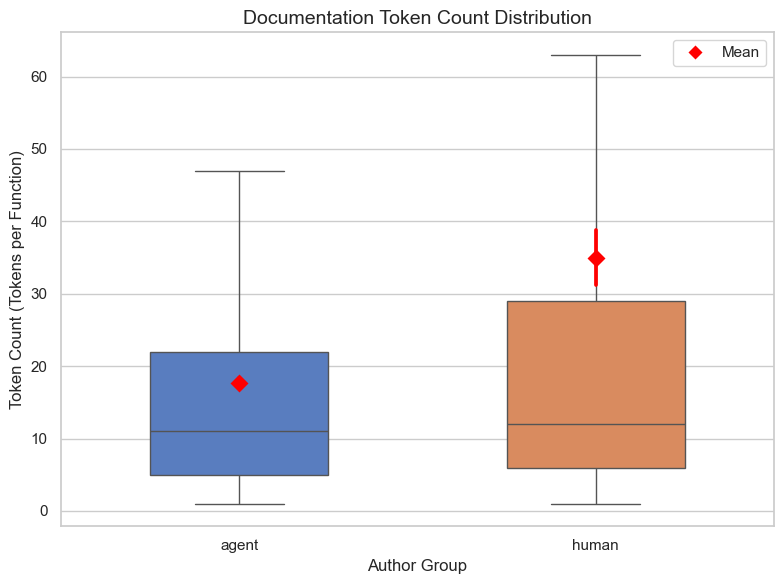

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style for a research paper
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 1. Standard Box Plot (Truncated at 100 tokens to keep it readable)
ax = sns.boxplot(
    x="group", 
    y="doc_token_count", 
    data=df, 
    palette="muted",
    showfliers=False, # This hides the dots for outliers to focus on the quartiles
    width=0.5
)

# Add the Mean as a point (crucial since your mean and median differ so much)
sns.pointplot(
    x="group", 
    y="doc_token_count", 
    data=df, 
    estimator="mean", 
    color="red", 
    markers="D", 
    linestyles="", 
    label="Mean"
)

plt.title("Documentation Token Count Distribution", fontsize=14)
plt.ylabel("Token Count (Tokens per Function)", fontsize=12)
plt.xlabel("Author Group", fontsize=12)

# Professional touch: add a legend for the Mean marker
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='D', color='w', label='Mean',
                          markerfacecolor='red', markersize=8)]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [20]:
from lexicalrichness import LexicalRichness
import re
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# 1. Your specific Tokenizer
def tokenize(text):
    if not isinstance(text, str) or not text.strip():
        return []
    return re.findall(r"[A-Za-z_][A-Za-z0-9_]*", text.lower())

# 2. Wrapper for LexicalRichness
def get_lexical_metrics(text):
    tokens = tokenize(text)
    if len(tokens) < 1:
        return np.nan, np.nan
    
    # We join tokens with spaces so LexicalRichness can process the string 
    # using your tokenization logic

    lex = LexicalRichness(text)
    
    # Return TTR and MTLD (MTLD is better for varying lengths)
    # Note: MTLD requires a minimum number of tokens (usually >10)
    try:
        return lex.ttr, lex.mtld(threshold=0.72)
    except:
        return lex.ttr, np.nan

# 3. Apply to Dataset
df_analysis = df[df['doc_text'].notna() & (df['doc_text'].str.strip() != "")].copy()
results = df_analysis['doc_text'].apply(get_lexical_metrics)
df_analysis[['ttr', 'mtld']] = pd.DataFrame(results.tolist(), index=df_analysis.index)

# 4. Statistical Comparison for TTR
agent_ttr = df_analysis[df_analysis['group'] == 'agent']['ttr'].dropna()
human_ttr = df_analysis[df_analysis['group'] == 'human']['ttr'].dropna()

u_stat, p_val = mannwhitneyu(agent_ttr, human_ttr)
n1, n2 = len(agent_ttr), len(human_ttr)
rank_biserial = 1 - (2 * u_stat / (n1 * n2))

# 5. Output
print(f"--- TTR (using lexical_richness) ---")
print(f"Agent Median: {agent_ttr.median():.4f} | Human Median: {human_ttr.median():.4f}")
print(f"P-value: {p_val:.4e} | Effect Size (r): {rank_biserial:.4f}")

# 6. Check MTLD (The more robust metric)
agent_mtld = df_analysis[df_analysis['group'] == 'agent']['mtld'].dropna()
human_mtld = df_analysis[df_analysis['group'] == 'human']['mtld'].dropna()
u_m, p_m = mannwhitneyu(agent_mtld, human_mtld)
print(f"\n--- MTLD (Length Independent) ---")
print(f"Agent Median: {agent_mtld.median():.2f} | Human Median: {human_mtld.median():.2f}")
print(f"MTLD P-value: {p_m:.4e}")

--- TTR (using lexical_richness) ---
Agent Median: 0.9333 | Human Median: 0.9167
P-value: 3.2105e-03 | Effect Size (r): -0.0435

--- MTLD (Length Independent) ---
Agent Median: 12.00 | Human Median: 14.00
MTLD P-value: 2.1132e-10
